# Gravitational Wave Data Analysis — Hands-On Session

## Exploring GW250114_082203 with Open Data

Welcome! In this hands-on session we will work with **real gravitational-wave data** from the LIGO, Virgo, and KAGRA detectors. Our target is the event **GW250114_082203**, a compact binary coalescence detected during the O4 observing run.

### What we'll do today

1. **Download open data** from [GWOSC](https://gwosc.org) for both LIGO detectors (Hanford H1 and Livingston L1)
2. **Inspect the raw strain data** in the time domain
3. **Estimate the noise Power Spectral Density (PSD)** using Welch's method
4. **Whiten and band-pass** the data to reveal the gravitational-wave signal

By the end of this notebook, you should be able to **see the GW signal with your own eyes** in the whitened data from both detectors!

> **Note**: This notebook is adapted from the [GW Open Data Workshop](https://github.com/gw-odw/odw) tutorials. All data used are publicly available through GWOSC.</VSCode.Cell>


## 1. Setup: Importing the tools we need

We will use three main Python packages:

- **[GWpy](https://gwpy.readthedocs.io/)** — the go-to package for GW data access and manipulation, built on an object-oriented design
- **[PyCBC](https://pycbc.org/)** — a powerful toolkit used in real GW searches and parameter estimation
- **[GWOSC](https://pypi.org/project/gwosc/)** — a lightweight client to query the GW Open Science Center catalog

We'll also use **NumPy**, **SciPy**, and **Matplotlib** for numerics and plotting.</VSCode.Cell>


In [1]:
# Suppress harmless warnings
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Core scientific packages
import numpy as np
import scipy
import matplotlib.pyplot as plt

# GW-specific packages
import gwosc
print(f"GWOSC version: {gwosc.__version__}")
import gwpy
print(f"GWpy version: {gwpy.__version__}")
import pycbc
print(f"PyCBC version: {pycbc.__version__}")

# For nice plots
#%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12


GWOSC version: 0.7.1
GWpy version: 3.0.11
PyCBC version: 2.8.1


## 2. Downloading Open Data from GWOSC

### The event: GW250114_082203

The event name follows the standard LIGO-Virgo-KAGRA convention: **GW** _YYMMDD_HHMMSS_. So **GW250114_082203** was detected on **January 14, 2025 at 08:22:03 UTC**, during the second half of the O4 observing run (O4b).

We'll download data from both LIGO detectors:
- **H1** — LIGO Hanford (Washington, USA)
- **L1** — LIGO Livingston (Louisiana, USA)

We'll fetch 32 seconds of data centred on the event time (16 seconds before and after). The `TimeSeries.fetch_open_data` method from GWpy handles the download automatically from the GWOSC server.</VSCode.Cell>


In [6]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

# Get the GPS time of the event
gps = event_gps('GW250114_082203')
print(f"GPS time of GW250114_082203: {gps}")

# Define a 32-second window around the event (±16 s)
segment = (int(gps) - 16, int(gps) + 16)
print(f"Data segment: {segment} (GPS seconds)")

# The event may have a fractional GPS offset, so compute its exact position
# within our segment (in seconds from segment start)
event_time_offset = gps - int(gps)  # fractional part of GPS time
event_time_in_segment = 16.0 + event_time_offset
print(f"Event at {event_time_in_segment:.3f} s within the {segment[1]-segment[0]} s segment")

GPS time of GW250114_082203: 1420878141.2
Data segment: (1420878125, 1420878157) (GPS seconds)
Event at 16.200 s within the 32 s segment


In [7]:
# Download data for both LIGO detectors
# This may take a minute or two, depending on your internet connection
print("\nDownloading H1 (Hanford) data...")
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True)

print("\nDownloading L1 (Livingston) data...")
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)

print("\n✓ Data successfully downloaded!")
print(f"  H1: {hdata}")
print(f"  L1: {ldata}")

print("\nStoring data to local files...")
hdata.write("GW250114_082203_H1.gwf")
ldata.write("GW250114_082203_L1.gwf")
print("✓ Data successfully stored!")


Fetched 1 URLs from gwosc.org for [1420878125 .. 1420878157))
Reading data... [Done]

Fetched 1 URLs from gwosc.org for [1420878125 .. 1420878157))
Reading data... [Done]

✓ Data successfully downloaded!
  H1: [ 2.91895016e-18  2.88285156e-18  2.80302209e-18 ...
 -5.86269147e-18 -5.85822698e-18 -5.80162525e-18]
  L1: [ 8.05896748e-18  8.09240812e-18  8.12321642e-18 ...
 -2.84578614e-18 -2.86961523e-18 -2.89358842e-18]

Storing data to local files...
✓ Data successfully stored!


In [ ]:
## You can also load the data from local files if you have already downloaded them:
#hdata = TimeSeries.read("GW250114_082203_H1.gwf")
#ldata = TimeSeries.read("GW250114_082203_L1.gwf")

## 3. Inspecting the Raw Data

Let's look at the raw strain data in the time domain. The strain $h(t)$ is a dimensionless quantity measuring the fractional change in distance between the interferometer's test masses:

$$h(t) = \frac{\Delta L(t)}{L}$$

Typical GW signals produce strains of order $h \sim 10^{-21}$ to $10^{-22}$, while the detector noise is typically $10^{-22}$ to $10^{-23}$ per $\sqrt{\text{Hz}}$. This means that **raw strain data is completely dominated by noise** — you cannot see the signal by eye!</VSCode.Cell>


In [13]:
# Let's check the basic properties of our data
T_h = hdata.duration.value   # total duration in seconds
dt_h = hdata.dt.value         # time step (1 / sampling frequency)
fs_h = 1.0 / dt_h             # sampling frequency in Hz

T_l = ldata.duration.value
dt_l = ldata.dt.value
fs_l = 1.0 / dt_l

print(f"H1 — Duration: {T_h} s,  dt: {dt_h:.6f} s,  fs: {fs_h:.0f} Hz")
print(f"L1 — Duration: {T_l} s,  dt: {dt_l:.6f} s,  fs: {fs_l:.0f} Hz")


H1 — Duration: 32.0 s,  dt: 0.000244 s,  fs: 4096 Hz
L1 — Duration: 32.0 s,  dt: 0.000244 s,  fs: 4096 Hz


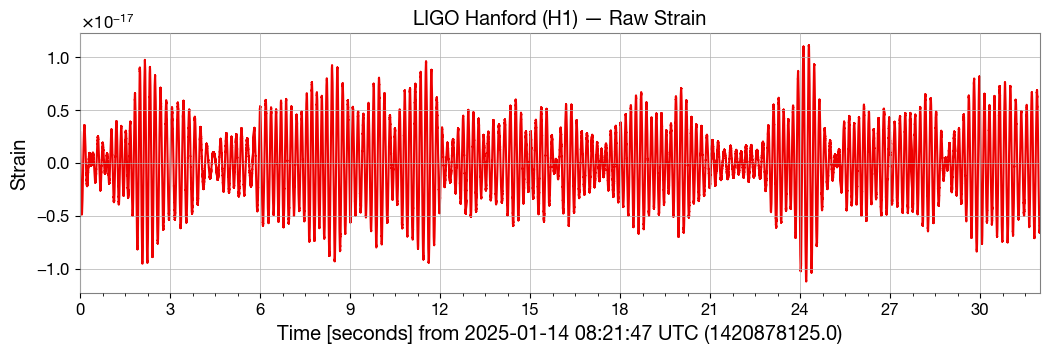

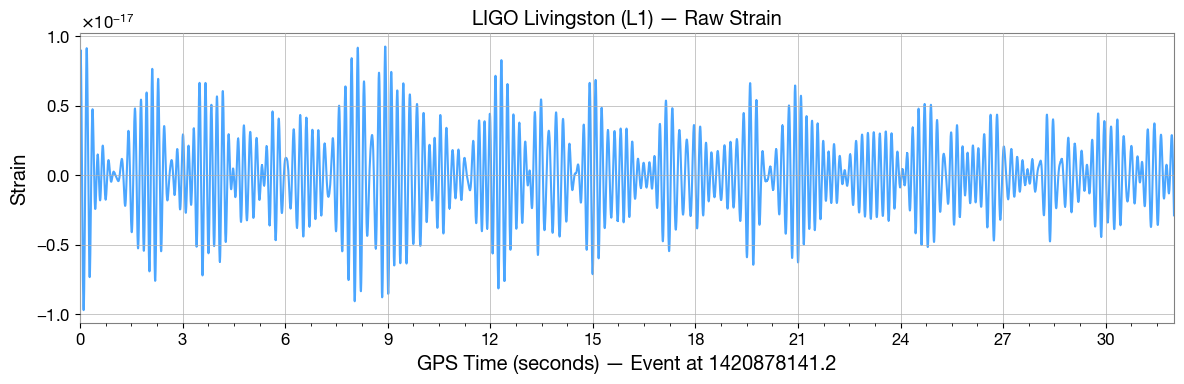

In [14]:
# Plot the raw strain data for both detectors

# H1 (Hanford)
plot_h = hdata.plot( color='gwpy:ligo-hanford')
plot_h.axes[0].set_title('LIGO Hanford (H1) — Raw Strain')
plot_h.axes[0].set_ylabel('Strain')

# L1 (Livingston)
plot_l = ldata.plot( color='gwpy:ligo-livingston')
plot_l.axes[0].set_title('LIGO Livingston (L1) — Raw Strain')
plot_l.axes[0].set_xlabel(f'GPS Time (seconds) — Event at {gps}')
plot_l.axes[0].set_ylabel('Strain')

plt.tight_layout()


As expected, the raw data looks like noise — the GW signal is completely buried. The data oscillates wildly because the dominant noise power lives at low frequencies (seismic noise below ~30 Hz) and high frequencies (shot noise above a few kHz). To reveal the signal, we need to:

1. **Characterise the noise** → estimate the Power Spectral Density (PSD)
2. **Whiten the data** → rescale by the PSD to flatten the noise spectrum
3. **Band-pass the data** → keep only the frequency range where the signal lives</VSCode.Cell>


## 4. The Power Spectral Density (PSD)

### What is the PSD?

The noise in a GW detector is a **stochastic process** $n(t)$. For stationary noise (noise whose statistical properties don't change over time), the **Power Spectral Density** $S_n(f)$ captures how the noise power is distributed across frequencies:

$$S_{n}(f) = \lim_{T \rightarrow +\infty} \frac{2}{T} \left\langle \left| \tilde{n}_{T}(f) \right|^{2} \right\rangle$$

where $\tilde{n}_T(f)$ is the Fourier transform of a noise segment of length $T$, and $\langle \cdot \rangle$ denotes an ensemble average.

A crucial property of stationary Gaussian noise: **different frequency bins are statistically independent**, with variance:

$$\langle \tilde{n}(f) \tilde{n}^*(f') \rangle = \frac{1}{2} S_n(f) \, \delta(f - f')$$

The square root of the PSD is called the **Amplitude Spectral Density (ASD)** and has units of $\text{strain} / \sqrt{\text{Hz}}$. The ASD is the standard way to visualise detector sensitivity.

### Estimating the PSD with Welch's method

Since we only have one realisation of the noise (not an ensemble), we estimate the PSD using **[Welch's method](https://en.wikipedia.org/wiki/Welch%27s_method)**:

1. Split the data into overlapping segments
2. Apply a window function to each segment (to reduce spectral leakage)
3. Compute the FFT of each segment
4. Average the squared magnitudes of all segments

There is a **trade-off**: longer segments give better frequency resolution ($\Delta f = 1/T_{\text{seg}}$), but fewer segments means more statistical fluctuations in the estimate.</VSCode.Cell>


In [15]:
# Compute PSD using Welch's method with scipy
# nperseg controls segment length: 4096 samples → frequency resolution ≈ fs/4096
fs = fs_h  # Use H1 sampling rate (should be same for both detectors)

freqs_h, psd_h = scipy.signal.welch(hdata.value, fs, window='hann', nperseg=4096)
freqs_l, psd_l = scipy.signal.welch(ldata.value, fs, window='hann', nperseg=4096)

print(f"PSD frequency bins: {len(freqs_h)}")
print(f"Frequency resolution: {freqs_h[1] - freqs_h[0]:.3f} Hz")


PSD frequency bins: 2049
Frequency resolution: 1.000 Hz


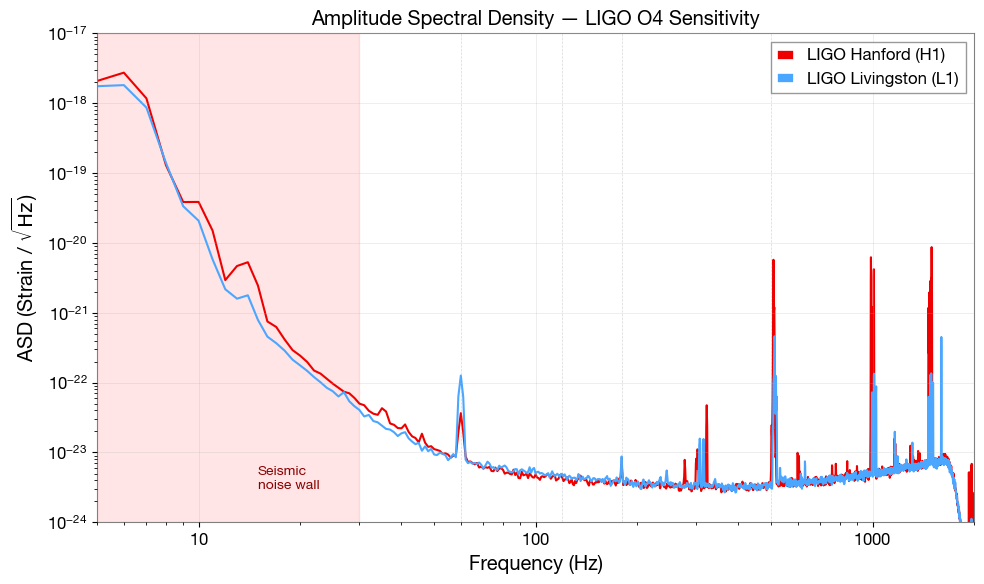

In [18]:
# Plot the Amplitude Spectral Density (ASD = sqrt(PSD)) for both detectors
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Skip the zero-frequency bin (freqs[0] = 0)
ax.loglog(freqs_h[1:], np.sqrt(psd_h[1:]), label='LIGO Hanford (H1)', color='gwpy:ligo-hanford')
ax.loglog(freqs_l[1:], np.sqrt(psd_l[1:]), label='LIGO Livingston (L1)', color='gwpy:ligo-livingston')

ax.set_xlim(5, 2000)
ax.set_ylim(1e-24, 1e-17)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'ASD (Strain / $\sqrt{\mathrm{Hz}}$)')
ax.set_title('Amplitude Spectral Density — LIGO O4 Sensitivity')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate interesting features
ax.axvspan(5, 30, alpha=0.1, color='red')
ax.annotate('Seismic\nnoise wall', xy=(15, 3e-24), fontsize=10, color='darkred')

# Highlight spectral lines
for fline in [60, 120, 180, 500]:
    ax.axvline(fline, color='gray', alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()


### Interpreting the ASD

The ASD plot reveals the characteristic sensitivity curve of the LIGO detectors in O4:

- **Below ~20–30 Hz**: Seismic noise dominates — the ground shakes too much
- **~30–200 Hz**: The most sensitive band — where most GW signals are detected
- **~200–1000 Hz**: Thermal noise from the mirror suspensions and coatings
- **Above ~1000 Hz**: Shot noise from photon counting statistics dominates

The sharp vertical lines (e.g. at 60, 120, 180 Hz) are **spectral lines** — narrow-band noise from the electric power grid (60 Hz in the US) and its harmonics, plus calibration lines deliberately injected to track the detector response.

> **Note**: The two LIGO detectors (H1 and L1) have nearly identical design, but their noise curves differ slightly due to different local environments (Hanford, WA vs. Livingston, LA).</VSCode.Cell>


## 5. Whitening and Band-passing the Data

### Why whiten?

The raw strain data is **colored noise**: different frequencies have vastly different power (as we just saw in the ASD plot). This makes it impossible to see a GW signal by eye.

**Whitening** rescales the data in the frequency domain so that all frequency bins have the same variance:

$$\tilde{d}_j^{\rm w} \equiv \sqrt{\frac{2 \Delta f}{S_n(f_j)}} \, \tilde{d}_j$$

After whitening, the noise becomes **white** — every frequency bin contributes equally. The Fourier bins of white noise are independent Gaussian variables with $\sigma = 1$. In the code below we implement the same idea using NumPy's discrete `rfft/irfft` convention, where the corresponding whitening factor is `ASD / \sqrt{2\,dt}`.

### Why band-pass?

Even after whitening, data at very low frequencies (dominated by seismic noise) and very high frequencies (dominated by shot noise, and where the signal has negligible power) adds no useful information about the GW signal. We apply a **band-pass filter** to keep only the frequency range where the signal lives:

$$\tilde{d}_j^{\rm wbp}(f) \equiv \tilde{w}_{\rm bp}(f) \, \tilde{d}_j^{\rm w}(f)$$

where $\tilde{w}_{\rm bp}(f)$ smoothly tapers to zero at the band edges.

In [19]:
# Helper function: smooth band-pass window (Tukey-like tapering)
def bandpass_window(freqs, f_low, f_high, taper_width_low=5., taper_width_high=50.):
    """
    Create a band-pass window that smoothly tapers to zero at the edges.
    
    Parameters:
    - freqs: array of frequencies
    - f_low, f_high: passband limits (Hz)
    - taper_width_low, taper_width_high: width of the cosine taper at each edge (Hz)
    
    Returns:
    - window: array of same shape as freqs, values in [0, 1]
    """
    window = np.ones_like(freqs)
    
    # Taper at low frequencies: 0 at f_low, 1 at f_low + taper_width_low
    mask_low = (freqs > f_low) & (freqs < f_low + taper_width_low)
    window[mask_low] = 0.5 * (1 - np.cos(np.pi * (freqs[mask_low] - f_low) / taper_width_low))
    
    # Set to zero below f_low
    window[freqs <= f_low] = 0.0
    
    # Taper at high frequencies: 1 at f_high - taper_width_high, 0 at f_high
    mask_high = (freqs > f_high - taper_width_high) & (freqs < f_high)
    window[mask_high] = 0.5 * (1 + np.cos(np.pi * (freqs[mask_high] - (f_high - taper_width_high)) / taper_width_high))
    
    # Set to zero above f_high
    window[freqs >= f_high] = 0.0
    
    return window


def whiten_bandpass(data_timeseries, asd_func, f_low=20, f_high=400, 
                    taper_low=10., taper_high=100.):
    """
    Whiten and band-pass a GWpy TimeSeries.
    
    Parameters:
    - data_timeseries: GWpy TimeSeries object
    - asd_func: interpolation function for the ASD (Hz → ASD value)
    - f_low, f_high: band-pass limits (Hz)
    - taper_low, taper_high: taper widths (Hz)
    
    Returns:
    - times: time array (seconds from start)
    - whitened_td: whitened, band-passed time-domain data
    - window_bp: the band-pass window used
    - freqs_fd: the positive-frequency grid used in the FFT
    """
    N = len(data_timeseries)
    dt = data_timeseries.dt.value
    
    # Apply a time-domain Tukey window to limit edge transients before the FFT
    tukey_win = scipy.signal.windows.tukey(N, alpha=0.1)
    data_windowed = tukey_win * data_timeseries.value
    
    # Use the standard NumPy FFT convention for time-domain whitening.
    # With this convention, dividing by ASD / sqrt(2*dt) gives a whitened
    # time series whose unfiltered samples have RMS close to 1 for stationary noise.
    data_fd = np.fft.rfft(data_windowed)
    freqs_fd = np.fft.rfftfreq(N, d=dt)
    whiten_norm = asd_func(freqs_fd) / np.sqrt(2 * dt)
    
    # Build the band-pass window and suppress frequencies outside the signal band.
    window_bp = bandpass_window(freqs_fd, f_low, f_high, taper_low, taper_high)
    data_wbp = window_bp * data_fd / whiten_norm
    
    # Transform back to the time domain using the matching inverse FFT convention.
    data_wbp_td = np.fft.irfft(data_wbp, n=N)
    times = dt * np.arange(len(data_wbp_td))
    
    return times, data_wbp_td, window_bp, freqs_fd

In [20]:
# Compute ASDs using GWpy's built-in method (for the interpolation functions)
asd_h = hdata.asd(fftlength=2., method="median")
asd_l = ldata.asd(fftlength=2., method="median")

# Create interpolation functions for the ASDs
from scipy.interpolate import interp1d
asd_h_interp = interp1d(asd_h.frequencies.value, asd_h.value, 
                         bounds_error=False, fill_value=np.inf)
asd_l_interp = interp1d(asd_l.frequencies.value, asd_l.value,
                         bounds_error=False, fill_value=np.inf)

# Whiten and band-pass both detectors
# For a compact binary merger, the interesting frequencies are ~20–500 Hz
print("Whitening H1 data...")
times_h, h_wbp, window_h, freqs_fd_h = whiten_bandpass(
    hdata, asd_h_interp, f_low=20, f_high=500, taper_low=10., taper_high=100.
)

print("Whitening L1 data...")
times_l, l_wbp, window_l, freqs_fd_l = whiten_bandpass(
    ldata, asd_l_interp, f_low=20, f_high=500, taper_low=10., taper_high=100.
)

# For white noise, band-passing reduces the time-domain RMS by roughly sqrt(mean(window^2)).
expected_rms_h = np.sqrt(np.mean(window_h**2))
expected_rms_l = np.sqrt(np.mean(window_l**2))

print("✓ Whitening complete!")
print(f"  H1 whitened data shape: {h_wbp.shape}")
print(f"  L1 whitened data shape: {l_wbp.shape}")
print(f"  H1 filtered RMS: {np.std(h_wbp):.3f}  (expected ≈ {expected_rms_h:.3f})")
print(f"  L1 filtered RMS: {np.std(l_wbp):.3f}  (expected ≈ {expected_rms_l:.3f})")
print("  RMS < 1 is expected here: whitening makes the full-band noise unit scale, and band-passing removes part of that variance.")


Whitening H1 data...
Whitening L1 data...
✓ Whitening complete!
  H1 whitened data shape: (131072,)
  L1 whitened data shape: (131072,)
  H1 filtered RMS: 0.450  (expected ≈ 0.448)
  L1 filtered RMS: 0.454  (expected ≈ 0.448)
  RMS < 1 is expected here: whitening makes the full-band noise unit scale, and band-passing removes part of that variance.


### Sanity check: the ASD and FFT normalization

Before looking at the time domain, let's verify that our ASD estimate is consistent with the Fourier-domain data. For the convention `dt × rfft(data)`, stationary noise should satisfy

$$|\tilde{d}(f)| \sim \frac{\mathrm{ASD}(f)}{\sqrt{2\,\Delta f}}$$

up to random scatter from one frequency bin to the next. This is a **frequency-domain PSD check**. The time-domain whitening used below adopts a different normalization, chosen so that the unfiltered whitened samples have RMS close to 1 for stationary noise; after the 20–500 Hz band-pass, the RMS becomes smaller because only part of the full band is retained.

### How to interpret the filtered RMS

At this stage there are **two different but compatible sanity checks**:

1. In the **frequency domain**, the PSD-normalized spectrum should sit at order unity across the passband.
2. In the **time domain**, the *unfiltered* whitened noise would have RMS close to 1.
3. After the **20–500 Hz band-pass**, the RMS drops below 1 because we deliberately discard part of the noise power along with irrelevant frequencies.

For this notebook, the filtered RMS should be roughly set by $\sqrt{\langle w_{\rm bp}^2 \rangle}$, where $w_{\rm bp}(f)$ is the band-pass window. That gives a useful rule of thumb for deciding whether the whitening and filtering behave as expected.

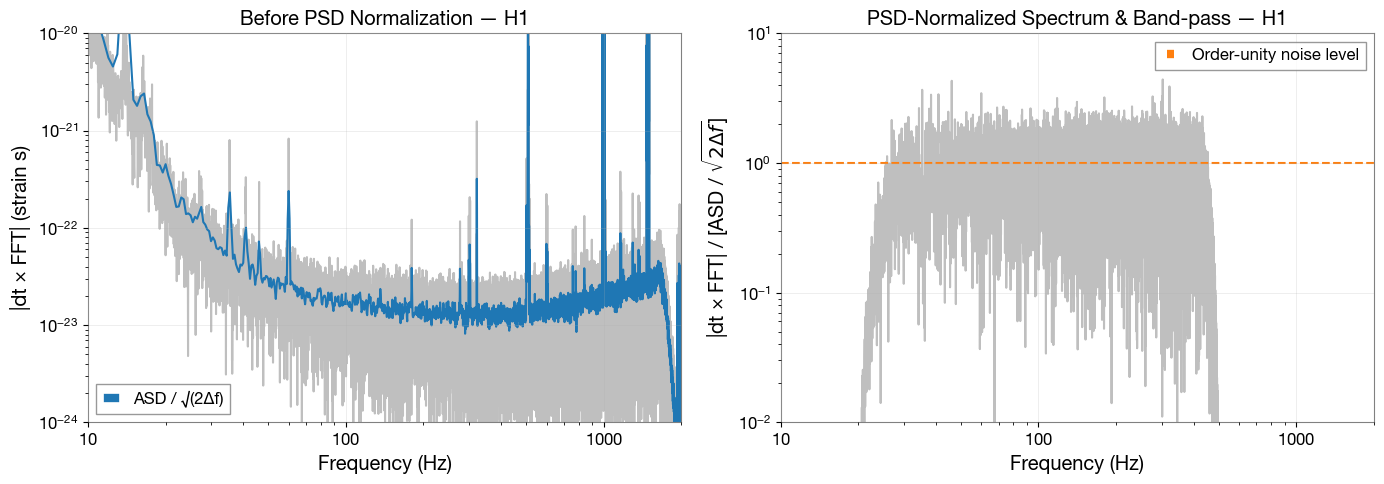

In [21]:
# Reconstruct the frequency-domain amplitudes for a PSD normalization check
N_h = len(hdata)
dt_h_val = hdata.dt.value
df_h = 1.0 / (N_h * dt_h_val)

# Use dt * rfft here because the one-sided PSD convention is
# S_n(f) ≈ (2 / T) |dt * rfft(data)|^2
tukey_h = scipy.signal.windows.tukey(N_h, alpha=0.1)
h_fd = np.fft.rfft(tukey_h * hdata.value) * dt_h_val
freqs_fd_h = np.fft.rfftfreq(N_h, d=dt_h_val)
h_fd_psdnorm = window_h * h_fd / (asd_h_interp(freqs_fd_h) / np.sqrt(2 * df_h))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before PSD normalization
axes[0].loglog(freqs_fd_h[1:], np.abs(h_fd[1:]), alpha=0.5, color='gray')
axes[0].loglog(asd_h.frequencies.value[1:], asd_h.value[1:] / np.sqrt(2 * df_h), 
               'C0', label='ASD / √(2Δf)')
axes[0].set_xlim(10, 2000)
axes[0].set_ylim(1e-24, 1e-20)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|dt × FFT| (strain s)')
axes[0].set_title('Before PSD Normalization — H1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After PSD normalization and band-limiting
axes[1].loglog(freqs_fd_h[1:], np.abs(h_fd_psdnorm[1:]), alpha=0.5, color='gray')
axes[1].axhline(1.0, color='C1', linestyle='--', label='Order-unity noise level')
axes[1].set_xlim(10, 2000)
axes[1].set_ylim(1e-2, 10)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'|dt × FFT| / [ASD / $\sqrt{2\Delta f}$]')
axes[1].set_title('PSD-Normalized Spectrum & Band-pass — H1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

## 6. Revealing the Gravitational-Wave Signal

Now for the exciting part! The whitened, band-passed time-domain data should show the GW signal clearly above the noise.

Remember: in whitened data, the noise is **white** before band-limiting. After we additionally restrict the data to 20–500 Hz, the residual time-domain noise has an RMS below 1 because we have removed most of the available frequency band. Any coherent structure that emerges on top of that filtered noise is a real feature of the data. A GW signal will appear as a **coherent oscillation that grows in amplitude and frequency**, peaking at the merger time, then ringing down.

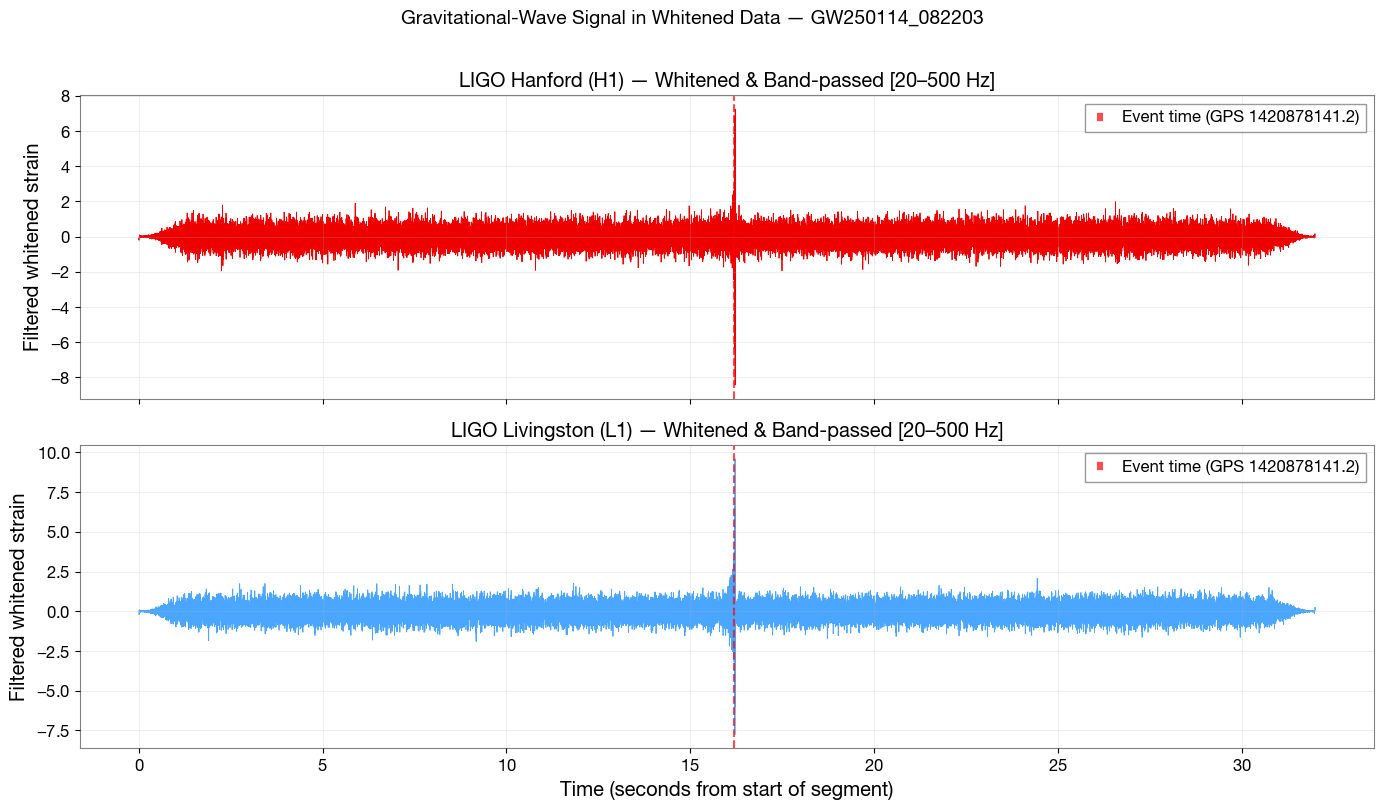

In [22]:
# Plot the whitened, band-passed time-domain data for BOTH detectors
# The event GPS time is at event_time_in_segment seconds from the start

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# H1
axes[0].plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.6)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7, label=f'Event time (GPS {gps})')
axes[0].set_ylabel('Filtered whitened strain')
axes[0].set_title('LIGO Hanford (H1) — Whitened & Band-passed [20–500 Hz]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# L1
axes[1].plot(times_l, l_wbp, color='gwpy:ligo-livingston', linewidth=0.6)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7, label=f'Event time (GPS {gps})')
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('Filtered whitened strain')
axes[1].set_title('LIGO Livingston (L1) — Whitened & Band-passed [20–500 Hz]')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gravitational-Wave Signal in Whitened Data — GW250114_082203', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()


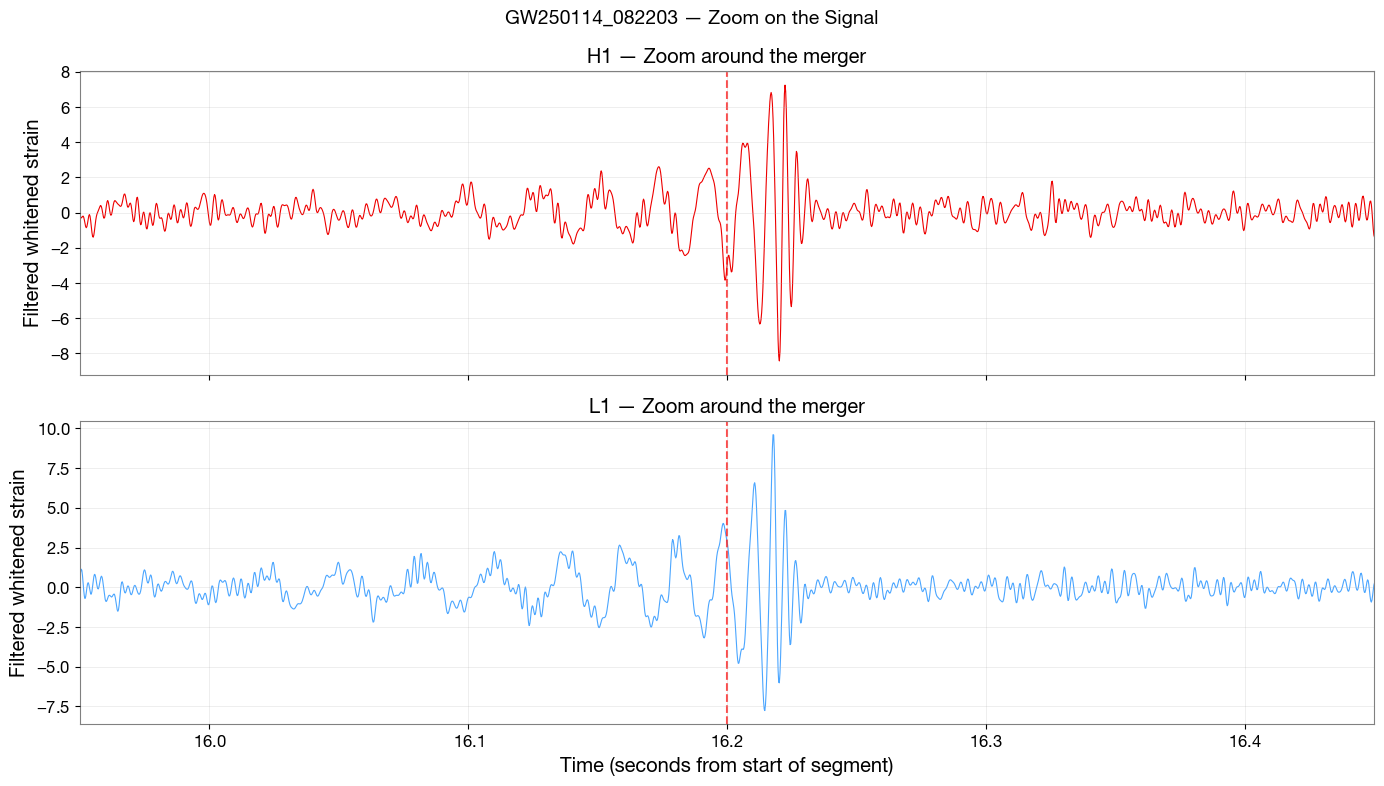

In [23]:
# Zoom in around the event time (±1 second)
zoom_halfwidth = 0.25
zoom_start = event_time_in_segment - zoom_halfwidth
zoom_end = event_time_in_segment + zoom_halfwidth

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.8)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlim(zoom_start, zoom_end)
axes[0].set_ylabel('Filtered whitened strain')
axes[0].set_title('H1 — Zoom around the merger')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_l, l_wbp, color='gwpy:ligo-livingston', linewidth=0.8)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlim(zoom_start, zoom_end)
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('Filtered whitened strain')
axes[1].set_title('L1 — Zoom around the merger')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GW250114_082203 — Zoom on the Signal', fontsize=14, fontweight='bold')
plt.tight_layout()


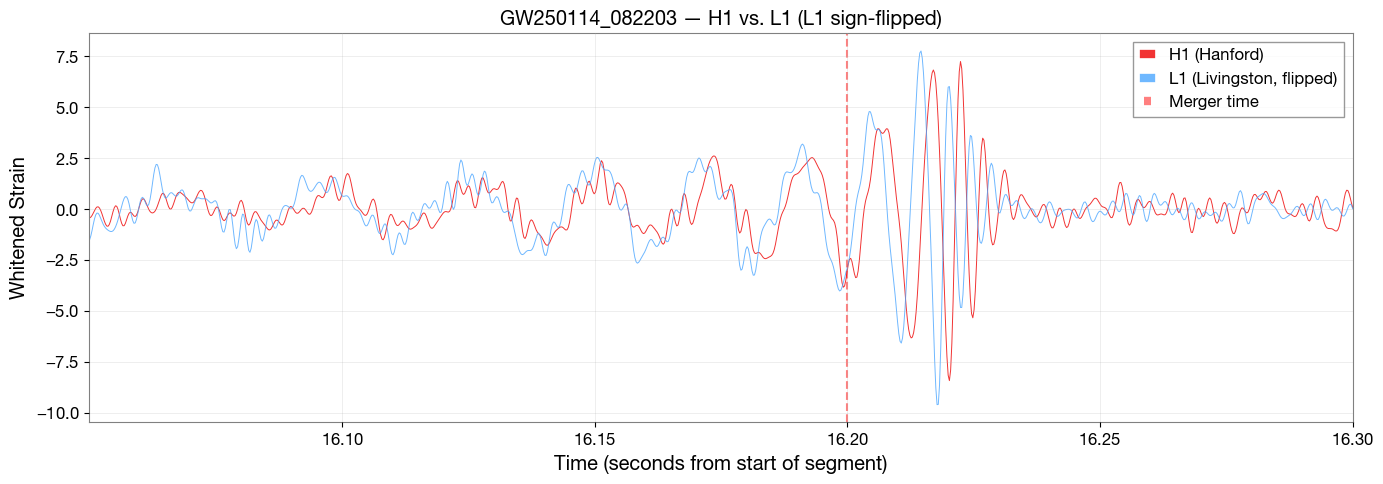

In [24]:
# Overlay both detectors for a direct comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.7, alpha=0.8, label='H1 (Hanford)')
ax.plot(times_l, -l_wbp, color='gwpy:ligo-livingston', linewidth=0.7, alpha=0.8, label='L1 (Livingston, flipped)')
ax.axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.5, label=f'Merger time')

ax.set_xlim(event_time_in_segment - 0.15, event_time_in_segment + 0.1)
ax.set_xlabel('Time (seconds from start of segment)')
ax.set_ylabel('Whitened Strain')
ax.set_title('GW250114_082203 — H1 vs. L1 (L1 sign-flipped)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()


### What do we see?

The whitened, band-passed data reveals a clear **chirp-like signal** — the hallmark of a compact binary coalescence:

1. **Inspiral**: The signal starts at low amplitude and high frequency, slowly growing. The binary's orbit shrinks due to gravitational-wave emission.

2. **Merger**: A sharp peak in amplitude as the two objects plunge together.

3. **Ringdown**: A rapid decay as the merged remnant settles into a stable state.

We can see the signal in **both detectors** (H1 and L1). In the overlay plot, we flipped the sign of L1 — this is because the detectors have different orientations, and a GW signal can appear with opposite sign in different detectors (or even be absent in one, if the source is in a blind spot). The fact that we see a **coherent, consistent signal in both detectors** is a strong indicator that this is a real astrophysical event, not a detector glitch!

### Why does whitening work?

Without whitening, the data is coloured noise — low frequencies dominate the raw strain by orders of magnitude. The GW signal lives in a narrow band and is completely drowned out. After dividing by the ASD, every frequency contributes equally, and the signal — which is a coherent pattern across frequency — stands out above the now-uniform white noise background.</VSCode.Cell>


## 7. Spectrograms: a short and clear view of the chirp

For a quick pedagogical view, we will make spectrograms from the **already whitened and band-passed** data from Section 5. This suppresses low-frequency seismic noise and makes the chirp easier to isolate.

Minimal recipe:
1. Use short FFTs (`fftlength = 0.064 s`) and high overlap for better time tracking.
2. Zoom tightly around merger (`+-0.20 s`) and focus on the most informative band (`30-350 Hz`).
3. Plot **excess power**: divide each frequency bin by its median over time. This removes broad stationary background and highlights the transient chirp.
4. Use logarithmic color scaling (`LogNorm`) on this excess-power map.

This keeps the section short while making the signal track much easier to see in both detectors.

If the track is still faint: set twin=0.15 or lower fmax to 250 Hz.


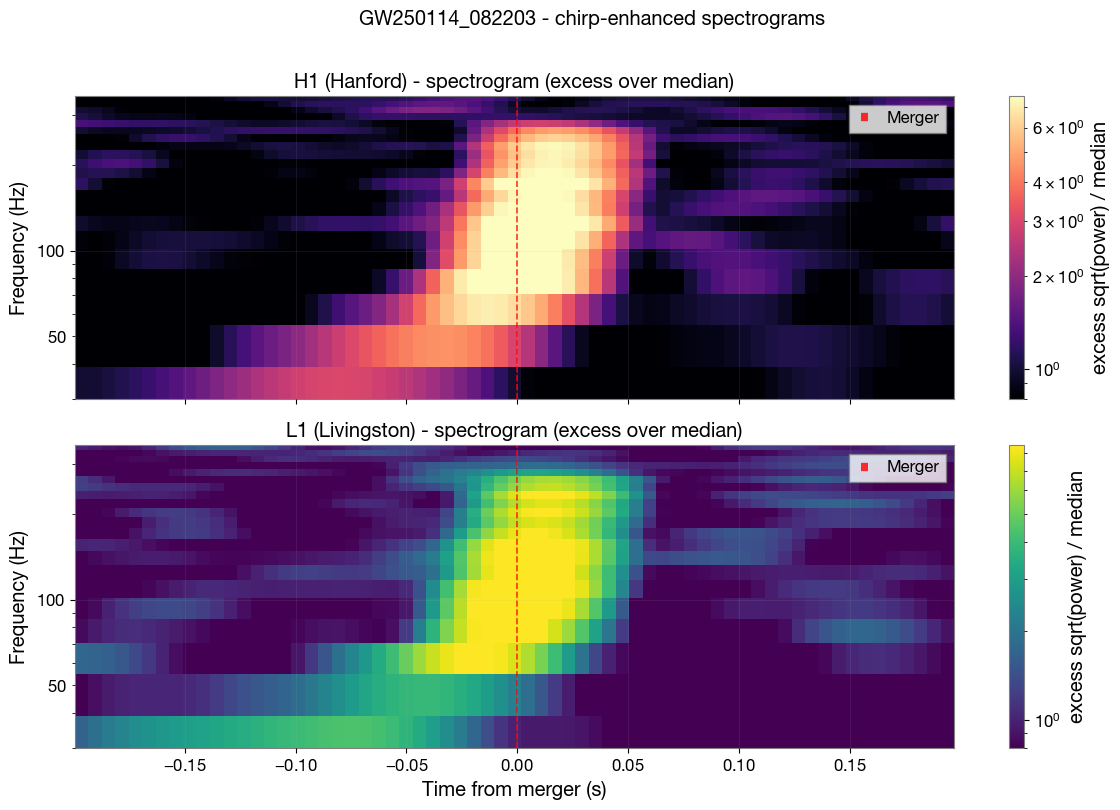

In [25]:
# Compact, pedagogical spectrogram view focused on signal visibility
from matplotlib.colors import LogNorm
from gwpy.timeseries import TimeSeries

# Reuse filtered-whitened data from Section 5 to enhance transient visibility
h_wbp_ts = TimeSeries(h_wbp, dt=hdata.dt.value, t0=hdata.t0.value)
l_wbp_ts = TimeSeries(l_wbp, dt=ldata.dt.value, t0=ldata.t0.value)

fftlength = 0.064   # s -> better time localization for short BBH chirp
overlap = 0.058      # s -> smooth time evolution
fmin, fmax = 30, 350
twin = 0.20          # seconds around merger

def make_zoomed_spec(ts):
    spec = ts.spectrogram2(fftlength=fftlength, overlap=overlap, window='hann') ** 0.5
    times_rel = spec.times.value - gps
    tmask = (times_rel >= -twin) & (times_rel <= twin)
    z = spec.value[tmask, :]

    # Pedagogical trick: normalize each frequency bin by its time-median
    # to suppress stationary background and highlight transient excess power.
    floor = np.percentile(z[z > 0], 1) if np.any(z > 0) else 1e-12
    bg = np.median(z, axis=0, keepdims=True)
    z_excess = z / np.maximum(bg, floor)

    positive = z_excess[z_excess > 0]
    vmin = 0.8
    vmax = np.percentile(positive, 99.5) if positive.size else 5.0
    if vmax <= vmin:
        vmax = vmin * 5.0

    return spec, times_rel[tmask], z_excess, vmin, vmax

spec_h, t_h, z_h, vmin_h, vmax_h = make_zoomed_spec(h_wbp_ts)
spec_l, t_l, z_l, vmin_l, vmax_l = make_zoomed_spec(l_wbp_ts)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, spec, tt, zz, vmin, vmax, title, cmap in [
    (axes[0], spec_h, t_h, z_h, vmin_h, vmax_h, 'H1 (Hanford)', 'magma'),
    (axes[1], spec_l, t_l, z_l, vmin_l, vmax_l, 'L1 (Livingston)', 'viridis'),
]:
    pcm = ax.pcolormesh(
        tt,
        spec.frequencies.value,
        zz.T,
        shading='auto',
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label='Merger')
    ax.set_yscale('log')
    ax.set_ylim(fmin, fmax)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'{title} - spectrogram (excess over median)')
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper right')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('excess sqrt(power) / median')

axes[1].set_xlabel('Time from merger (s)')
plt.suptitle('GW250114_082203 - chirp-enhanced spectrograms', fontweight='bold', y=1.01)
plt.tight_layout()

print('If the track is still faint: set twin=0.15 or lower fmax to 250 Hz.')

## 8. Summary

In this hands-on tutorial, we have:

| Step | What we did | Key takeaway |
|---|---|---|
| **1. Data access** | Downloaded 32 s of real LIGO strain for GW250114_082203 using GWpy | GWOSC provides free, open access to GW data |
| **2. Raw inspection** | Plotted the time-domain strain | Raw data is dominated by coloured noise; signals are invisible |
| **3. PSD estimation** | Computed the ASD using Welch's method | The PSD captures how noise power is distributed across frequencies |
| **4. Whitening** | Divided the FFT by the ASD | Whitening flattens the noise spectrum so all frequencies have equal weight |
| **5. Band-passing** | Kept only 20–500 Hz with smooth tapers | Removing irrelevant frequencies reduces background fluctuations |
| **6. Signal reveal** | Plotted the whitened time-domain data | **The GW chirp signal is clearly visible in both H1 and L1!** |
| **7. Spectrogram** | Computed time-frequency spectrograms of both detectors | **The chirp track is visible as a sweeping curve in the time-frequency plane!** |

---

### Where to go from here

- **Matched filtering**: The next step is to use matched filtering (Tutorial 4.1–4.2) to quantify how significant this signal is
- **Parameter estimation**: Once detected, we use Bayesian inference (Tutorial 5.1–5.2) to measure the source properties (masses, spins, distance)
- **Explore other events**: Try the same analysis on other events — GW150914 (the first detection), GW170817 (the first binary neutron star merger), or any event from the [GWOSC catalog](https://gwosc.org/eventapi/)

---

*This notebook uses data from the Gravitational Wave Open Science Center (GWOSC), a service of LIGO Laboratory, the LIGO Scientific Collaboration, the Virgo Collaboration, and KAGRA.*

## 9. Generating a Template Waveform

We've seen the GW signal by eye in the whitened data. But how do we **quantify** its presence? The answer is **matched filtering**: cross-correlating the data with a theoretical template waveform that predicts what the signal should look like.

### First, get the source parameters

To generate the right template, we need to know the binary's parameters. The GWOSC catalog provides these from the LIGO-Virgo-KAGRA parameter estimation analyses. Let's fetch the published values for GW250114_082203.

We'll use `gwosc.api.fetch_event_json()` to get the source-frame masses, redshift, and other key parameters.

In [26]:
from gwosc.api import fetch_event_json

# Fetch the event parameters from the GWOSC catalog (GWTC-5.0)
event_data = fetch_event_json('GW250114_082203')

# The event key includes the version tag; extract it
event_key = list(event_data['events'].keys())[0]
params = event_data['events'][event_key]

# Print a summary of the key parameters
print("=" * 55)
print(f"  {params['commonName']}  —  {params['catalog.shortName']}")
print("=" * 55)
print(f"  Mass 1 (source-frame):   {params['mass_1_source']:>6.1f}  (+{params['mass_1_source_upper']:.1f} / {params['mass_1_source_lower']:.1f})  M☉")
print(f"  Mass 2 (source-frame):   {params['mass_2_source']:>6.1f}  (+{params['mass_2_source_upper']:.1f} / {params['mass_2_source_lower']:.1f})  M☉")
print(f"  Total mass (source):     {params['total_mass_source']:>6.1f}  (+{params['total_mass_source_upper']:.1f} / {params['total_mass_source_lower']:.1f})  M☉")
print(f"  Chirp mass (source):     {params['chirp_mass_source']:>6.1f}  (+{params['chirp_mass_source_upper']:.1f} / {params['chirp_mass_source_lower']:.1f})  M☉")
print(f"  Effective spin (χ_eff):  {params['chi_eff']:>6.2f}  (+{params['chi_eff_upper']:.2f} / {params['chi_eff_lower']:.2f})")
print(f"  Luminosity distance:    {params['luminosity_distance']:>6.0f}  (+{params['luminosity_distance_upper']:.0f} / {params['luminosity_distance_lower']:.0f})  Mpc")
print(f"  Redshift:               {params['redshift']:>6.2f}  (+{params['redshift_upper']:.2f} / {params['redshift_lower']:.2f})")
print(f"  Network SNR:            {params['network_matched_filter_snr']:>6.1f}")
print(f"  FAR:                    {params['far']:.2e}  yr⁻¹")
print("=" * 55)

# Store the key numbers we'll need
m1_source = params['mass_1_source']
m2_source = params['mass_2_source']
redshift = params['redshift']
chi_eff = params['chi_eff']
published_snr = params['network_matched_filter_snr']


  GW250114_082203  —  GWTC-5.0
  Mass 1 (source-frame):     33.8  (+1.3 / -0.9)  M☉
  Mass 2 (source-frame):     32.3  (+0.9 / -1.5)  M☉
  Total mass (source):       66.0  (+1.1 / -1.2)  M☉
  Chirp mass (source):       28.7  (+0.5 / -0.5)  M☉
  Effective spin (χ_eff):   -0.03  (+0.04 / -0.05)
  Luminosity distance:       405  (+84 / -73)  Mpc
  Redshift:                 0.09  (+0.02 / -0.01)
  Network SNR:              78.6
  FAR:                    1.00e-05  yr⁻¹


### From source frame to detector frame

The masses reported by GWOSC are **source-frame masses** — the masses in the binary's rest frame. However, gravitational waves are stretched by cosmological redshift $z$ in the same way as light: frequencies arriving at the detector are $f_{\rm det} = f_{\rm source} / (1+z)$. This means the detector "sees" **redshifted masses**:

$$m_{\rm det} = m_{\rm source} \times (1+z)$$

For GW250114, $z \approx 0.09$, so the detector-frame masses are about 9% larger than the source-frame masses listed above.

### Generating the template

Now we generate a theoretical waveform using the published parameters. We'll use `IMRPhenomD`, a fast frequency-domain model that describes the inspiral, merger, and ringdown of non-precessing binary black holes. Since GW250114 has $\chi_{\rm eff} \approx -0.03$ (essentially zero spin), this model is well-suited.

We pass the **detector-frame** masses to `get_td_waveform` and match the sampling rate of our data.

In [27]:
from pycbc.waveform import get_td_waveform

# Convert the catalog masses from source frame to detector frame
m1_det = m1_source * (1.0 + redshift)
m2_det = m2_source * (1.0 + redshift)

# Use a simple non-precessing configuration consistent with chi_eff ≈ 0.
# The overall amplitude is not important for matched filtering because the SNR
# divides by the template norm sigma.
hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=m1_det,
    mass2=m2_det,
    spin1z=chi_eff,
    spin2z=chi_eff,
    delta_t=hdata.dt.value,
    f_lower=20.0,
    distance=1.0
    )

print(f"Detector-frame masses: m1 = {m1_det:.1f} M☉, m2 = {m2_det:.1f} M☉")
print(f"Template waveform: {len(hp)} samples, duration = {len(hp) * hp.delta_t:.2f} s")
print(f"Template starts at t = {float(hp.start_time):.2f} s (merger at t=0)")

/Users/hestelles/miniconda3/envs/igwn-py312/lib/python3.12/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


lal.MSUN_SI != Msun
Detector-frame masses: m1 = 36.8 M☉, m2 = 35.2 M☉
Template waveform: 65536 samples, duration = 16.00 s
Template starts at t = -11.00 s (merger at t=0)


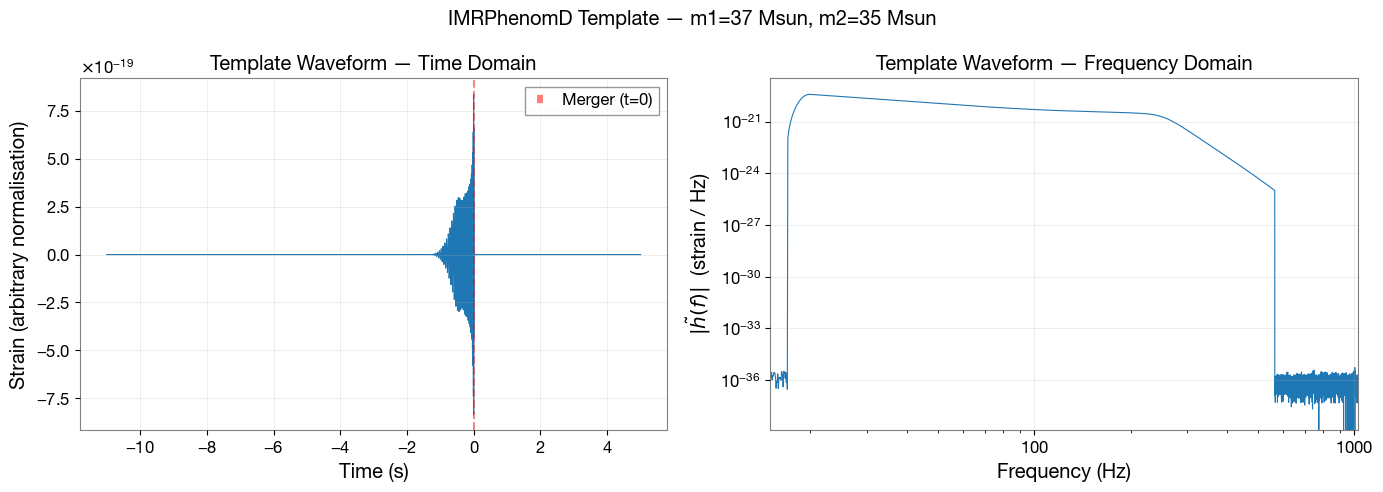

In [28]:
# Plot the template in both time and frequency domains
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time domain: the chirp waveform
axes[0].plot(hp.sample_times, hp, color='C0', linewidth=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Merger (t=0)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Strain (arbitrary normalisation)')
axes[0].set_title('Template Waveform — Time Domain')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Frequency domain: |h̃(f)|
hp_fd = hp.to_frequencyseries()
axes[1].loglog(hp_fd.sample_frequencies, abs(hp_fd), color='C0', linewidth=0.8)
axes[1].set_xlim(15, 1024)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'$|\tilde{h}(f)|$  (strain / Hz)')
axes[1].set_title('Template Waveform — Frequency Domain')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'IMRPhenomD Template — m1={m1_det:.0f} Msun, m2={m2_det:.0f} Msun', 
             fontweight='bold')
plt.tight_layout()


## 10. Matched Filtering — The Noise-Weighted Inner Product

### What is matched filtering?

Matched filtering is the **optimal method** for detecting a known signal buried in stationary, Gaussian noise. The idea is to cross-correlate the data $d(t) = n(t) + h(t)$ with a template $h(t)$ that predicts the expected signal shape.

The key tool is the **noise-weighted inner product**:

$$(a \mid b) \equiv 4 \, \Re \int_{0}^{\infty} \frac{\tilde{a}^*(f) \, \tilde{b}(f)}{S_n(f)} \, df$$

where $S_n(f)$ is the one-sided power spectral density of the noise. In discrete form (with frequency spacing $\Delta f$):

$$(a \mid b) \approx 4 \, \Delta f \sum_{k} \frac{\tilde{a}^*(f_k) \, \tilde{b}(f_k)}{S_n(f_k)}$$

### The Signal-to-Noise Ratio

Given data $d$ and a template $h$, the **signal-to-noise ratio** $\rho$ is:

$$\rho = \frac{(d \mid h)}{\sqrt{(h \mid h)}}$$

where $\sigma \equiv \sqrt{(h \mid h)}$ is the template's self-norm. A template normalised so that $(h \mid h) = 1$ is said to have $\sigma = 1$, and then $\rho = (d \mid h)$ directly.

The SNR can be computed at **all possible arrival times** by sliding the template across the data. This yields a **time series** $\rho(t)$, and the time of the maximum $\rho$ is our best estimate of the merger time.

### Computing the inner product

We already have everything we need: the data (`hdata`), the ASD (`asd_h`), and the template (`hp`). Let's compute:

1. **$\sigma$** — the template normalisation factor
2. **$\rho$ at the event time** — the SNR of our template matched to the data at the published merger time
3. **$\rho(t)$** — the full SNR time series via FFT-based cross-correlation

In [29]:
# ============================================================
#  Manual SNR computation using the noise-weighted inner product
# ============================================================

N = len(hdata)
dt_val = hdata.dt.value
df = 1.0 / (N * dt_val)

# Apply a Tukey window to suppress edge effects in the FFT
tukey = scipy.signal.windows.tukey(N, alpha=0.1)

# ---- Compute the template norm σ = sqrt((h|h)) ----
# Pad the template to the same length as the data
template_padded = np.zeros(N)
n_hp = len(hp)
template_padded[:n_hp] = hp.numpy()

# FFT with the dt prefactor (consistent with the rest of the notebook)
#   dtilde(f_k) = dt × Σ_j d_j × exp(−2π i j k / N)
template_fd_rfft = np.fft.rfft(tukey * template_padded) * dt_val
freqs_rfft = np.fft.rfftfreq(N, d=dt_val)

# Evaluate the ASD at the RFFT frequency grid
asd_rfft = asd_h_interp(freqs_rfft)
asd_rfft[0] = asd_rfft[1]

# σ² = (h|h) = 4 × Δf × Σₖ |h̃(fₖ)|² / Sₙ(fₖ)
sigma_sq = 4.0 * np.sum(np.abs(template_fd_rfft) ** 2 / (asd_rfft ** 2)) * df
sigma = np.sqrt(sigma_sq)
print(f"Template norm σ = sqrt((h|h)) = {sigma:.3f}")
print(f"→ A template with σ=1 would give SNR = (d|h) directly.")

# FFT of the data (reused below)
data_fd_rfft = np.fft.rfft(tukey * hdata.value) * dt_val

# ---- Full SNR time series via FFT convolution ----
# Keep the template in its natural waveform convention, where the merger is at
# t = 0 but the array starts at hp.start_time < 0. The matched-filter peak is
# therefore referenced to the template start time and must be shifted by
# -hp.start_time to report the merger time inside the data segment.
data_fd_full = np.fft.fft(tukey * hdata.value) * dt_val
template_fd_full = np.fft.fft(tukey * template_padded) * dt_val
freqs_full = np.fft.fftfreq(N, d=dt_val)

# One-sided ASD evaluated at |f|
asd_full = asd_h_interp(np.abs(freqs_full))
asd_full[0] = asd_full[1]

# Matched-filter integrand on the full FFT grid.
# Because positive and negative frequencies are both present here, the full-grid
# version carries a factor of 2 instead of the factor of 4 used on the one-sided grid.
integrand_full = 2.0 * np.conj(data_fd_full) * template_fd_full / (asd_full ** 2) * df

# Forward FFT implements the e^{−2π i f t} phase convention used above
z_complex = np.fft.fft(integrand_full)
snr_manual = np.abs(z_complex) / sigma

# Shift the time axis from template-start convention to merger-time convention
times_mf = dt_val * np.arange(N) - float(hp.start_time)

# Read off the SNR at the published event time
idx_event = np.argmin(np.abs(times_mf - event_time_in_segment))
snr_at_event = snr_manual[idx_event]
print(f"\nSNR at the published event time: ρ = {snr_at_event:.1f}")
print("  The peak can occur a few × 10 ms away because this template only approximates the true source parameters.")

# Find the peak
peak_idx = np.argmax(snr_manual)
snr_peak_manual = snr_manual[peak_idx]
peak_time = float(times_mf[peak_idx])

print(f"SNR peak (manual): ρ = {snr_peak_manual:.1f} at t = {peak_time:.4f} s")
print(f"Event is at       t = {event_time_in_segment:.4f} s")
print(f"Time offset: {peak_time - event_time_in_segment:.4f} s")

Template norm σ = sqrt((h|h)) = 33457.537
→ A template with σ=1 would give SNR = (d|h) directly.

SNR at the published event time: ρ = 0.5
  The peak can occur a few × 10 ms away because this template only approximates the true source parameters.
SNR peak (manual): ρ = 48.9 at t = 16.2229 s
Event is at       t = 16.2000 s
Time offset: 0.0229 s



Published network SNR: 78.6  (H1 + L1 combined)
Our H1-only SNR:       48.9
→ H1 contributes roughly half the network SNR, as expected for a 2-detector network.


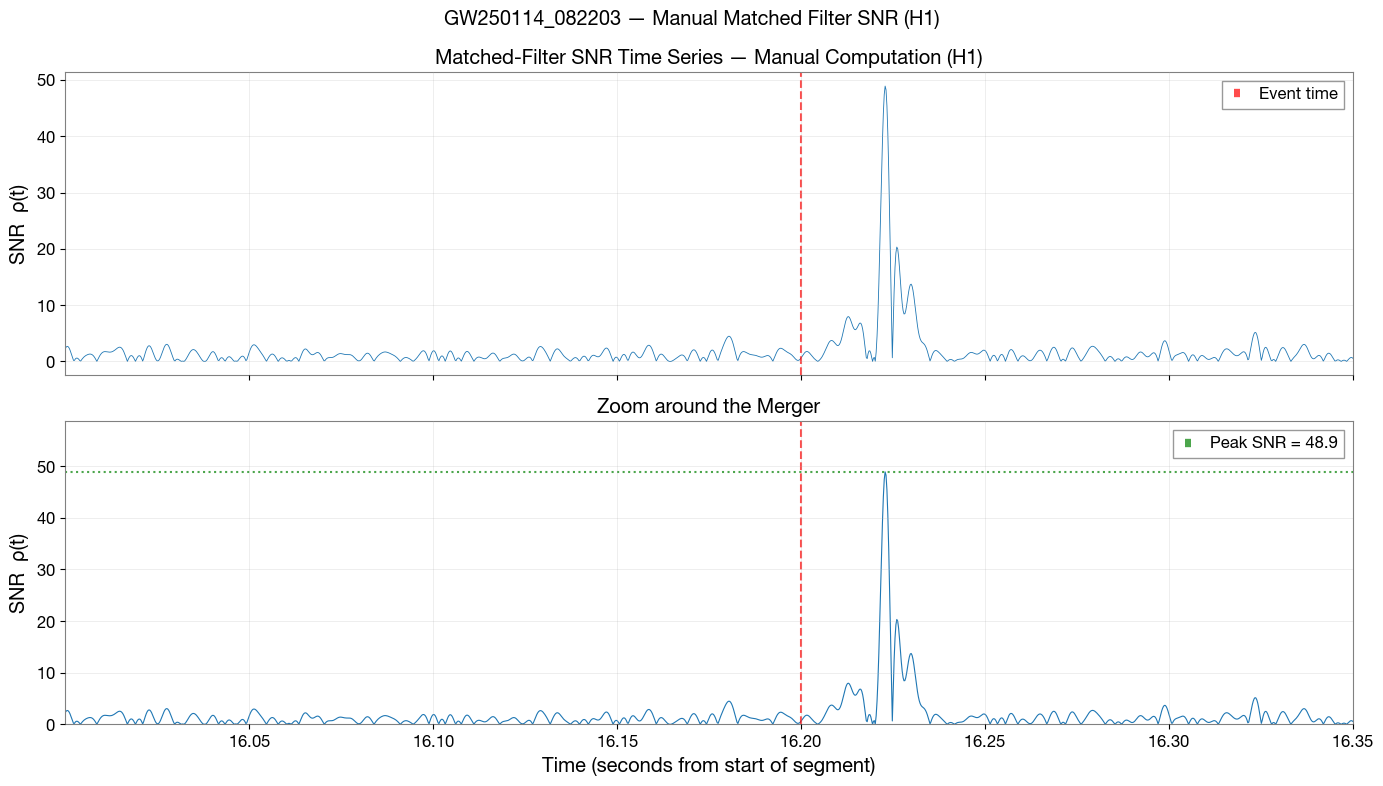

In [30]:
# Plot the manual SNR time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Full view
axes[0].plot(times_mf, snr_manual, color='C0', linewidth=0.6)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7,
                label=f'Event time')
axes[0].set_ylabel('SNR  ρ(t)')
axes[0].set_title('Matched-Filter SNR Time Series — Manual Computation (H1)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Zoom around the peak
axes[1].plot(times_mf, snr_manual, color='C0', linewidth=0.8)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(y=snr_peak_manual, color='green', linestyle=':', alpha=0.7,
                label=f'Peak SNR = {snr_peak_manual:.1f}')
axes[1].set_xlim(event_time_in_segment - 0.2, event_time_in_segment + 0.15)
axes[1].set_ylim(0, snr_peak_manual * 1.2)
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('SNR  ρ(t)')
axes[1].set_title('Zoom around the Merger')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GW250114_082203 — Manual Matched Filter SNR (H1)', fontweight='bold')
plt.tight_layout()

print(f"\nPublished network SNR: {published_snr:.1f}  (H1 + L1 combined)")
print(f"Our H1-only SNR:       {snr_peak_manual:.1f}")
print(f"→ H1 contributes roughly half the network SNR, as expected for a 2-detector network.")


## 11. Matched Filtering with PyCBC

The manual implementation above gives the right answer, but in practice we use **PyCBC's `matched_filter`**, which is optimised, handles edge effects carefully, and returns a **complex SNR** whose absolute value corresponds to the phase-maximised SNR.

### Complex SNR

A template $h(t)$ can match the data with any phase offset $\phi_0$: the real strain in the detector is a linear combination of the two polarisations, projected onto the detector's antenna pattern. The matched filter therefore correlates the data with both the in-phase template $h$ and the quadrature template $h_{\pi/2}$ (shifted by 90°):

$$z(t) = (d \mid h_t) + i \, (d \mid h_{t,\,\pi/2})$$

The **phase-maximised SNR** is $\rho(t) = |z(t)|$, and the best-fit phase is $\arg z(t)$.

### PyCBC implementation

PyCBC's `matched_filter` takes a template, the data, a PSD, and a low-frequency cutoff. It returns the complex SNR time series. We'll also use `pycbc.filter.sigma` to compute the template normalisation.

In [31]:
from pycbc.filter import matched_filter, sigma
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries as PyCBCTimeSeries

# ---- Prepare data in PyCBC format ----
# Convert the GWpy TimeSeries to a PyCBC TimeSeries
strain_pycbc = PyCBCTimeSeries(
    hdata.value,
    delta_t=hdata.dt.value,
    epoch=hdata.t0.value
    )

# Resize the template to match the data length
# (PyCBC templates need to be the same length as the data for matched_filter)
template = PyCBCTimeSeries(
    np.zeros(len(strain_pycbc)),
    delta_t=strain_pycbc.delta_t,
    epoch=strain_pycbc.start_time
    )
# Copy the waveform into the template (merger at t=0 in waveform convention)
n_wf = len(hp)
template.data[:n_wf] = hp.numpy()
# Cyclic time-shift so the merger is at the beginning of the array
template = template.cyclic_time_shift(hp.start_time)

# ---- Compute the PSD with PyCBC ----
# Use Welch's method with 4-second segments
psd_pycbc = strain_pycbc.psd(4)
psd_pycbc = interpolate(psd_pycbc, strain_pycbc.delta_f)
psd_pycbc = inverse_spectrum_truncation(
    psd_pycbc,
    int(4 * strain_pycbc.sample_rate),
    low_frequency_cutoff=15.0
    )

# ---- Run the matched filter ----
snr_pycbc = matched_filter(
    template, strain_pycbc,
    psd=psd_pycbc,
    low_frequency_cutoff=20.0
    )

# Crop to remove filter corruption at the edges
snr_pycbc = snr_pycbc.crop(8, 4)
times_pycbc = np.array([float(t - strain_pycbc.start_time) for t in snr_pycbc.sample_times])

# ---- Report the peak ----
peak_idx_pycbc = abs(snr_pycbc).data.argmax()
snr_peak_pycbc = float(abs(snr_pycbc[peak_idx_pycbc]))
peak_time_pycbc = float(times_pycbc[peak_idx_pycbc])

print("PyCBC matched filter results (H1):")
print(f"  Peak SNR:   ρ = {snr_peak_pycbc:.1f}")
print(f"  Peak time:  t = {peak_time_pycbc:.4f} s  (event at {event_time_in_segment:.4f} s)")
print(f"  Time diff:  Δt = {peak_time_pycbc - event_time_in_segment:.4f} s")
print(f"\n  Manual SNR peak was: {snr_peak_manual:.1f} at t = {peak_time:.4f} s")
print(f"  Agreement: Δρ = {abs(snr_peak_pycbc - snr_peak_manual):.2f}")


PyCBC matched filter results (H1):
  Peak SNR:   ρ = 52.3
  Peak time:  t = 16.2234 s  (event at 16.2000 s)
  Time diff:  Δt = 0.0234 s

  Manual SNR peak was: 48.9 at t = 16.2229 s
  Agreement: Δρ = 3.37


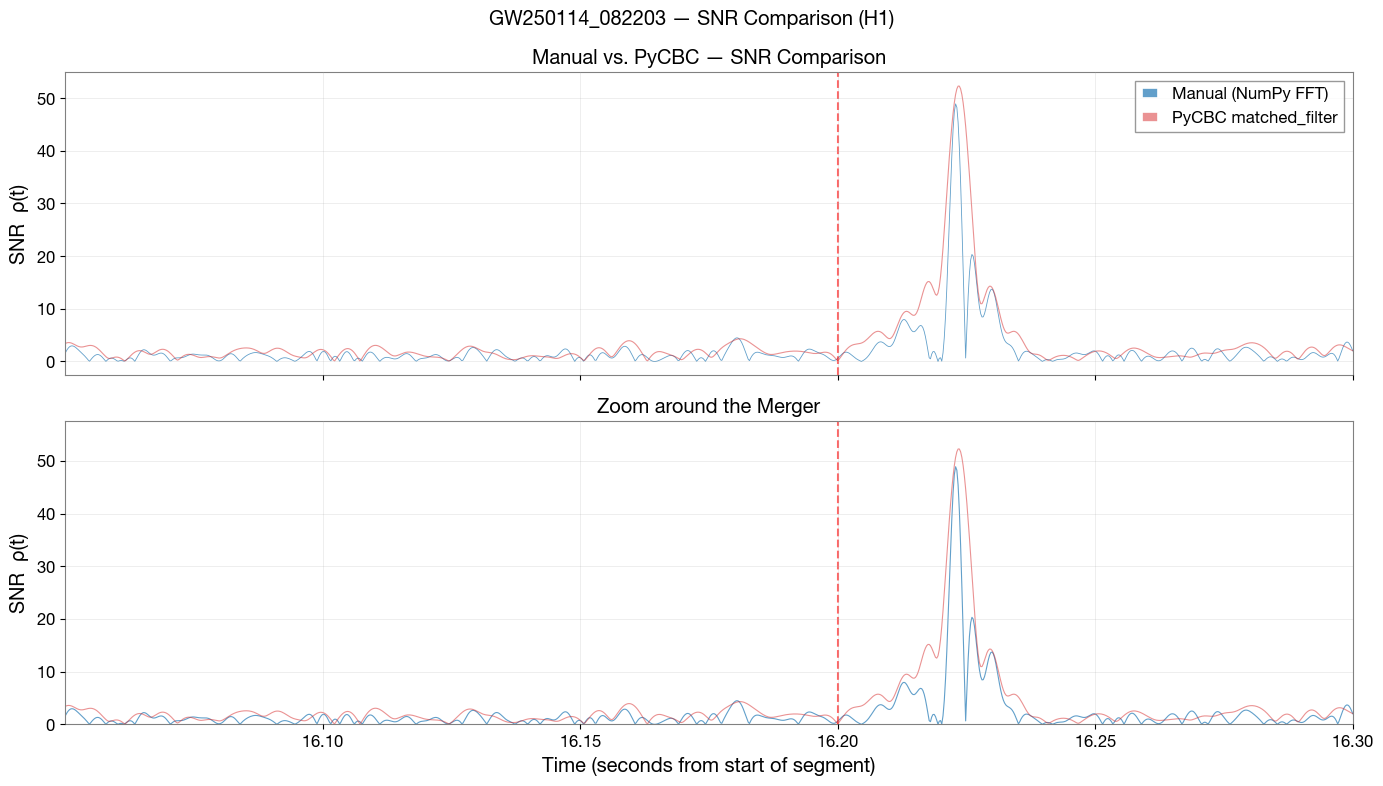

In [88]:
# ---- Compare manual and PyCBC SNR time series ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Full view
axes[0].plot(times_mf, snr_manual, color='C0', linewidth=0.6, alpha=0.7,
             label='Manual (NumPy FFT)')
axes[0].plot(times_pycbc, abs(snr_pycbc),
             color='C3', linewidth=0.8, alpha=0.5, label='PyCBC matched_filter')
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.6)
axes[0].set_ylabel('SNR  ρ(t)')
axes[0].set_title('Manual vs. PyCBC — SNR Comparison')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Zoom around the merger
axes[1].plot(times_mf, snr_manual, color='C0', linewidth=0.8, alpha=0.7)
axes[1].plot(times_pycbc, abs(snr_pycbc),
             color='C3', linewidth=0.8, alpha=0.5)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.6)
axes[1].set_xlim(event_time_in_segment - 0.15, event_time_in_segment + 0.1)
axes[1].set_ylim(0, snr_peak_pycbc * 1.1)
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('SNR  ρ(t)')
axes[1].set_title('Zoom around the Merger')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GW250114_082203 — SNR Comparison (H1)', fontweight='bold')
plt.tight_layout()


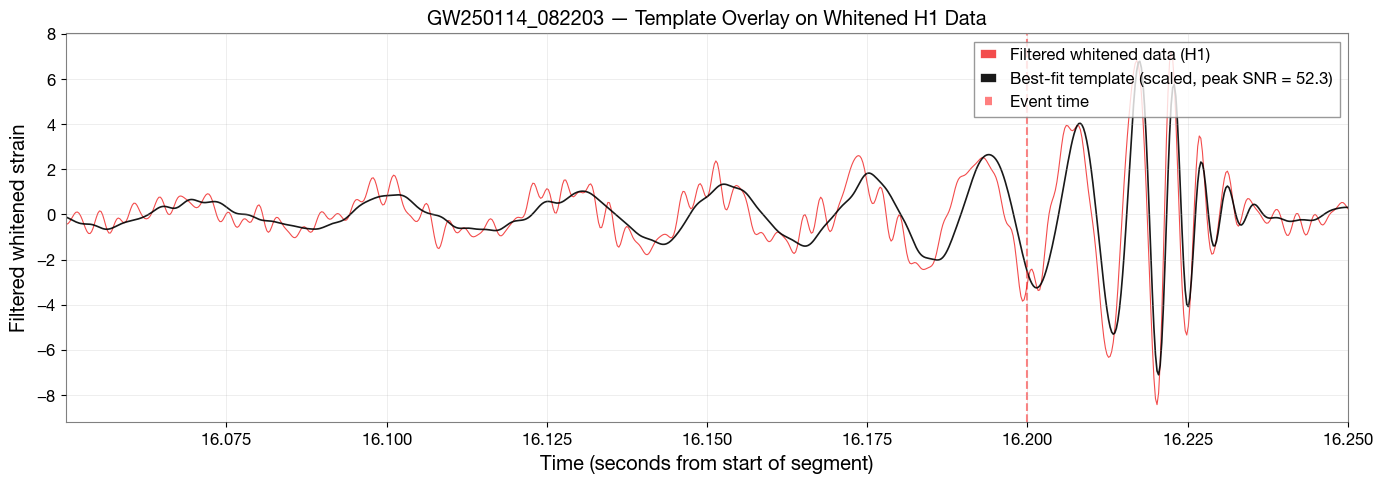

In [92]:
# ---- Build a best-fit template directly in the notebook whitening convention ----
# Align the template merger to the PyCBC peak time
shift_samples = int(round(peak_time_pycbc / dt_val)) - idx_merger_in_template
template_bestfit = np.roll(template_padded, shift_samples)
template_bestfit_ts = TimeSeries(template_bestfit, dt=hdata.dt.value, t0=0)

# Whiten and band-pass the aligned template the same way as the data
times_template, template_wbp_raw, _, _ = whiten_bandpass(
    template_bestfit_ts, asd_h_interp, f_low=20, f_high=500, taper_low=10., taper_high=100.
    )

# Fit a single amplitude so the template is shown in the same filtered-whitened units
t_start = event_time_in_segment - 0.15
t_end = event_time_in_segment + 0.05
plot_mask = (times_h >= t_start) & (times_h <= t_end)
template_norm = np.dot(template_wbp_raw[plot_mask], template_wbp_raw[plot_mask])
bestfit_scale = np.dot(h_wbp[plot_mask], template_wbp_raw[plot_mask]) / template_norm
template_wbp = bestfit_scale * template_wbp_raw

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.8,
        alpha=0.7, label='Filtered whitened data (H1)')
ax.plot(times_template, template_wbp, color='black', linewidth=1.2,
        alpha=0.9, label=f'Best-fit template (scaled, peak SNR = {snr_peak_pycbc:.1f})')
ax.axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.5,
           label='Event time')
ax.set_xlim(t_start, t_end)
ax.set_xlabel('Time (seconds from start of segment)')
ax.set_ylabel('Filtered whitened strain')
ax.set_title('GW250114_082203 — Template Overlay on Whitened H1 Data', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()


## 12. Signal Consistency — The Power χ² Test

A high SNR tells us there is **something** in the data that correlates with our template. But is that something really a gravitational-wave signal, or could it be a **noise transient (glitch)** that happens to resemble our template?

### The idea behind χ²

We can test the consistency of the data with our waveform model by asking: **does each frequency band contribute its fair share to the total SNR?**

The procedure (from [Allen 2005](https://arxiv.org/abs/gr-qc/0405045)):

1. **Divide the template into $p$ frequency bins**, chosen so that each bin would contribute roughly the same SNR in Gaussian noise
2. **Compute the SNR in each bin separately**, $\rho_i$
3. **Compare with the expected contribution** $\rho / p$:

$$\chi^2 = \sum_{i=1}^{p} \left|\rho_i - \frac{\rho}{p}\right|^2$$

4. **Normalise** by the number of degrees of freedom: $\chi^2_r = \chi^2 / (2p - 2)$, where $2p$ comes from the complex SNR having both real and imaginary parts, and $-2$ from the constraint that the bins sum to the total SNR

### Interpreting χ²ᵣ

- **$\chi^2_r \approx 1$**: the data is consistent with Gaussian noise plus a **search-grade template** that matches the signal very well
- **$\chi^2_r \gg 1$**: the frequency-by-frequency match is poor, either because the trigger is a glitch or because the template is only an approximate description of the true signal

In this notebook we use a **single approximate template** built from catalog median parameters, not the fully optimised template bank waveform used in a search pipeline. That means the SNR can still be high while $\chi^2_r$ remains large: the statistic is much more sensitive than the SNR to small phase and amplitude mismatches across frequency. The goal here is therefore to illustrate **how the χ² test is computed and why it is useful**, rather than to reproduce the exact search-pipeline χ² value.

In [95]:
from pycbc.vetoes import power_chisq

# ---- Compute the power χ² using the same template as the matched filter ----
nbins = 26  # standard choice: 26 frequency bins
chisq = power_chisq(
    template, strain_pycbc, nbins, psd_pycbc,
    low_frequency_cutoff=20.0
    )
chisq = chisq.crop(8, 4)

# Normalise by degrees of freedom
dof = 2 * nbins - 2
chisq_red = chisq / dof
chisq_times = np.array([float(t - strain_pycbc.start_time) for t in chisq_red.sample_times])

# ---- Report χ²ᵣ at the SNR peak ----
idx_peak = np.argmin(np.abs(chisq_times - peak_time_pycbc))
chisq_at_peak = float(chisq_red[idx_peak])
nearby_slice = chisq_red[max(0, idx_peak - 50):idx_peak + 50]
chisq_min_nearby = float(min(nearby_slice))

print(f"Power χ² test (H1, {nbins} bins, {dof} dof):")
print(f"  χ²ᵣ at SNR peak:  {chisq_at_peak:.3f}")
print(f"  χ²ᵣ min nearby:   {chisq_min_nearby:.3f}")
print("  Search-grade templates are expected to give χ²ᵣ ~ 1 for a true signal.")
print("  Our simplified single-template model gives a much larger value, showing that χ² is very sensitive to waveform mismatch.")


Power χ² test (H1, 26 bins, 50 dof):
  χ²ᵣ at SNR peak:  1253.181
  χ²ᵣ min nearby:   1252.279
  Search-grade templates are expected to give χ²ᵣ ~ 1 for a true signal.
  Our simplified single-template model gives a much larger value, showing that χ² is very sensitive to waveform mismatch.


Text(16.273388672, 1254.6805060697727, 'χ²ᵣ = 1253.18 at peak')

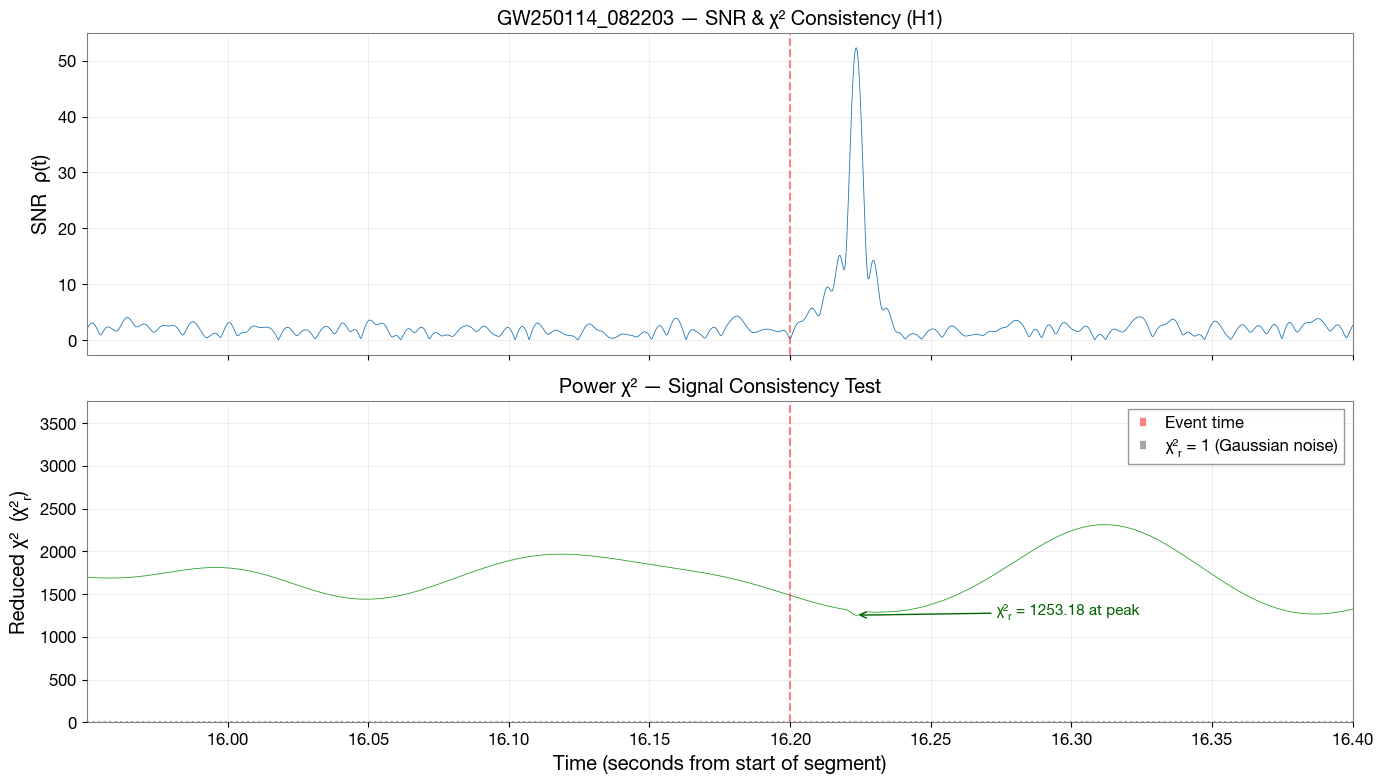

In [94]:
# ---- Plot χ²ᵣ and SNR together ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# SNR
axes[0].plot(times_pycbc, abs(snr_pycbc),
             color='C0', linewidth=0.6)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('SNR  ρ(t)')
axes[0].set_title(f'GW250114_082203 — SNR & χ² Consistency (H1)')
axes[0].grid(True, alpha=0.3)

# χ²ᵣ
axes[1].plot(chisq_times, chisq_red, color='C2', linewidth=0.6)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.5,
                label='Event time')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.7,
                label='χ²ᵣ = 1 (Gaussian noise)')
axes[1].set_xlim(event_time_in_segment - 0.25, event_time_in_segment + 0.2)
axes[1].set_ylim(0, max(5, chisq_at_peak * 3))
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('Reduced χ²  (χ²ᵣ)')
axes[1].set_title('Power χ² — Signal Consistency Test')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Annotate the dip
axes[1].annotate(
    f'χ²ᵣ = {chisq_at_peak:.2f} at peak',
    xy=(peak_time_pycbc, chisq_at_peak),
    xytext=(peak_time_pycbc + 0.05, chisq_at_peak + 1.5),
    arrowprops=dict(arrowstyle='->', color='darkgreen'),
    fontsize=11, color='darkgreen', fontweight='bold'
    )


## 13. Extended Summary — From Signal to Significance

We have now gone beyond "seeing" the signal to **quantifying** its presence and **testing** it against a waveform model. Here is the full picture:

| Step | What we did | Key result |
|---|---|---|
| **1. Data access** | Downloaded 32 s of LIGO strain for GW250114_082203 | GWOSC provides free, open access to GW data |
| **2. Raw inspection** | Plotted the time-domain strain | Raw data is dominated by coloured noise |
| **3. PSD estimation** | Computed the ASD using Welch's method | The PSD captures the noise power distribution |
| **4. Whitening** | Divided the FFT by the ASD | Whitening flattens the noise spectrum |
| **5. Band-passing** | Kept 20–500 Hz with smooth tapers | Removes irrelevant frequencies |
| **6. Signal reveal** | Plotted whitened time-domain data | **The GW chirp is clearly visible in both H1 and L1!** |
| **7. Spectrogram** | Computed time-frequency spectrograms for both detectors | **The chirp track sweeps across frequency, visible in the time-frequency plane** |
| **8. Template** | Fetched GWOSC catalog parameters, generated `IMRPhenomD` waveform | $m_1 \approx 36.8$ M$_\odot$, $m_2 \approx 35.2$ M$_\odot$ (detector-frame), $\chi_{\rm eff} \approx -0.03$ |
| **9. Manual SNR** | Computed $\rho = (d\mid h)/\sqrt{(h\mid h)}$ with NumPy FFT | H1-only peak SNR $\approx 49$ near the published event time |
| **10. PyCBC SNR** | Used `pycbc.filter.matched_filter` | Confirmed the manual timing and found H1 peak SNR $\approx 52$ |
| **11. χ² consistency** | Evaluated the power χ² statistic with the same approximate template | The large $\chi^2_r$ shows that χ² is much more sensitive than SNR to detailed waveform mismatch |

### What this tells us

- **The signal is extremely significant**: the matched-filter SNR is very large in H1 alone, and the published network SNR is 78.6
- **The timing is consistent**: both the manual and PyCBC matched filters peak within about 23 ms of the published event time
- **The χ² test is stricter than the SNR**: a single approximate template can recover a strong signal while still failing a detailed frequency-by-frequency consistency test

### Where to go from here

- **Search-grade template banks**: In a real search, the template parameters are optimised over a dense bank, which is why the pipeline obtains both high SNR and acceptable χ² values
- **Parameter estimation** (Tutorials 5.1–5.2): Use Bayesian inference to measure the masses, spins, and distance precisely — and explore the full posterior distribution
- **Multi-detector analysis**: Combine H1 and L1 coherently to improve the sky localisation

---

*This notebook uses data from the Gravitational Wave Open Science Center (GWOSC), a service of LIGO Laboratory, the LIGO Scientific Collaboration, the Virgo Collaboration, and KAGRA. GW250114_082203 parameters are from the GWTC-5.0 catalog.*

## 14. A Short Pedagogical Parameter Estimation Run

We can now reuse the catalog best estimates to run a very small Bayesian parameter-estimation demo. The goal is intentionally narrow: keep the sky position, orientation, spins, and distance fixed at the catalog values, and vary only the two component masses, the phase, and the coalescence time.

This is inspired by Tutorial 5.2 from GWOSC, but adapted to the data and template setup already built in this notebook.

In [62]:
! wget --no-verbose https://zenodo.org/api/records/20348006/files/IGWN-GWTC5p0-29ebe06b7_25-GW250114_082203-combined_PEDataRelease.hdf5/content

2026-07-07 12:26:22 URL:https://zenodo.org/api/records/20348006/files/IGWN-GWTC5p0-29ebe06b7_25-GW250114_082203-combined_PEDataRelease.hdf5/content [1735932504/1735932504] -> "content" [1]


In [73]:
import h5py
import pandas as pd

posterior_file = './content'
posterior = h5py.File(posterior_file, 'r')

In [83]:
samples_pe=pd.DataFrame.from_records(np.array(posterior['C00:IMRPhenomXPHM-SpinTaylor']['posterior_samples'][:]))


In [84]:
samples_pe.keys()

Index(['H1_log_likelihood', 'H1_matched_filter_snr', 'H1_optimal_snr',
       'L1_log_likelihood', 'L1_matched_filter_snr', 'L1_optimal_snr',
       'L1_time', 'a_1', 'a_2', 'azimuth',
       ...
       'final_mass_source', 'radiated_energy', 'H1_time', 'H1_L1_time_delay',
       'network_optimal_snr', 'network_matched_filter_snr',
       'network_precessing_snr', 'cos_theta_jn', 'viewing_angle', 'cos_iota'],
      dtype='object', length=141)

In [96]:
import bilby
from bilby.core.prior import Uniform
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters
from gwosc.api import fetch_event_json

print('Setting up a short PE run for GW250114_082203')
event_data = fetch_event_json('GW250114_082203')
event_key = list(event_data['events'].keys())[0]

m1_det = samples_pe['mass_1'].median()
m2_det = samples_pe['mass_2'].median()
print(f'Catalog detector-frame masses: m1 = {m1_det:.2f} Msun, m2 = {m2_det:.2f} Msun')

# Use a 4 s analysis window centered on the published trigger time.
pe_start = gps - 2
pe_end = gps + 2

H1_pe = bilby.gw.detector.get_empty_interferometer('H1')
L1_pe = bilby.gw.detector.get_empty_interferometer('L1')
H1_pe.set_strain_data_from_gwpy_timeseries(hdata.crop(pe_start, pe_end))
L1_pe.set_strain_data_from_gwpy_timeseries(ldata.crop(pe_start, pe_end))

# Estimate the PSD from the off-source data before the signal.
H1_psd_data_pe = hdata.crop(gps - 16, gps + 16)
L1_psd_data_pe = ldata.crop(gps - 16, gps + 16)
psd_alpha_pe = 2 * H1_pe.strain_data.roll_off / 4
H1_psd_pe = H1_psd_data_pe.psd(fftlength=4, overlap=0, window=('tukey', psd_alpha_pe), method='median')
L1_psd_pe = L1_psd_data_pe.psd(fftlength=4, overlap=0, window=('tukey', psd_alpha_pe), method='median')

H1_pe.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd_pe.frequencies.value, psd_array=H1_psd_pe.value)
L1_pe.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1_psd_pe.frequencies.value, psd_array=L1_psd_pe.value)

H1_pe.minimum_frequency = 20
H1_pe.maximum_frequency = 1024
L1_pe.minimum_frequency = 20
L1_pe.maximum_frequency = 1024

prior_pe = bilby.core.prior.PriorDict()
prior_pe['mass_1'] = Uniform(name='mass_1', minimum=m1_det - 5.0, maximum=m1_det + 5.0)
prior_pe['mass_2'] = Uniform(name='mass_2', minimum=m2_det - 5.0, maximum=m2_det + 5.0)
prior_pe['phase'] = Uniform(name='phase', minimum=0, maximum=2 * np.pi)
prior_pe['geocent_time'] = Uniform(name='geocent_time', minimum=gps - 0.1, maximum=gps + 0.1)
prior_pe['luminosity_distance'] = Uniform(name='luminosity_distance', minimum=100, maximum=2000)

catalog_distance = params['luminosity_distance'] if 'luminosity_distance' in params else 1000.0
catalog_ra = params['ra'] if 'ra' in params else 0.0
catalog_dec = params['dec'] if 'dec' in params else 0.0
catalog_theta_jn = params['theta_jn'] if 'theta_jn' in params else 0.0
catalog_psi = params['psi'] if 'psi' in params else 0.0

#prior_pe['luminosity_distance'] = catalog_distance
prior_pe['ra'] = samples_pe['ra'].median()
prior_pe['dec'] = samples_pe['dec'].median()
prior_pe['theta_jn'] = samples_pe['theta_jn'].median()
prior_pe['psi'] = samples_pe['psi'].median()
prior_pe['a_1'] = 0.0
prior_pe['a_2'] = 0.0
prior_pe['tilt_1'] = 0.0
prior_pe['tilt_2'] = 0.0
prior_pe['phi_12'] = 0.0
prior_pe['phi_jl'] = 0.0

waveform_arguments = dict(
    waveform_approximant='IMRPhenomD',
    reference_frequency=20.0,
    catch_waveform_errors=True,
)
waveform_generator_pe = bilby.gw.WaveformGenerator(
    duration=4,
    sampling_frequency=4096,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=waveform_arguments,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
)

likelihood_pe = bilby.gw.likelihood.GravitationalWaveTransient(
    [H1_pe, L1_pe],
    waveform_generator_pe,
    priors=prior_pe,
    time_marginalization=True,
    phase_marginalization=True,
    distance_marginalization=True,
)

print('PE setup complete. The next cell runs the sampler.')

/Users/hestelles/miniconda3/envs/igwn-py312/lib/python3.12/site-packages/gwpy/types/series.py:991: UserWarning: TimeSeries.crop given end larger than current end, crop will begin when the Series actually ends.
  warn(
15:01 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
15:01 bilby INFO    : Loaded distance marginalisation lookup table from .distance_marginalization_lookup.npz.


Setting up a short PE run for GW250114_082203
Catalog detector-frame masses: m1 = 36.64 Msun, m2 = 35.03 Msun
PE setup complete. The next cell runs the sampler.


In [98]:
result_pe = bilby.run_sampler(
    likelihood_pe,
    prior_pe,
    sampler='dynesty',
    outdir='pe_short',
    label='GW250114_short_pe',
    conversion_function=generate_all_bbh_parameters,
    nlive=512,
    dlogz=0.1,
    sample='rwalk',
    nact=1,
    walks=1,
    clean=True,
)

for parameter in ['mass_1', 'mass_2', 'phase', 'geocent_time']:
    samples = result_pe.posterior[parameter].values
    median = np.median(samples)
    lower = np.quantile(samples, 0.05)
    upper = np.quantile(samples, 0.95)
    print(f'{parameter}: median = {median:.6f}, 90% CI = [{lower:.6f}, {upper:.6f}]')

print(f'ln Bayes factor = {result_pe.log_bayes_factor} +/- {result_pe.log_evidence_err}')

15:03 bilby INFO    : Running for label 'GW250114_short_pe', output will be saved to 'pe_short'
15:03 bilby INFO    : Using lal version 7.7.0
15:03 bilby INFO    : Using lal git version Branch: None;Tag: lal-v7.7.0;Id: ef36dfdf49181b9b376a867b55a14463783de545;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
15:03 bilby INFO    : Using lalsimulation version 6.2.0
15:03 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsimulation-v6.2.0;Id: 1338470a6165fb4b4c98bccdd0efe961f05bc8e0;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
15:03 bilby INFO    : Analysis priors:
15:03 bilby INFO    : mass_1=Uniform(minimum=31.63618409616756, maximum=41.63618409616756, name='mass_1', latex_label='$m_1$', unit=None, boundary=None)
15:03 bilby INFO    : mass_2=Uniform(minimum=30.034902263217624, maximum=40.034902263217624, name='mass_2', latex_label='$m_2$', unit=None, boundary=None)
1

1it [00:00, ?it/s]

15:07 bilby INFO    : Written checkpoint file pe_short/GW250114_short_pe_resume.pickle
/Users/hestelles/miniconda3/envs/igwn-py312/lib/python3.12/site-packages/dynesty/plotting.py:252: RuntimeWarning: overflow encountered in exp
  np.exp(logwt), logz if logplot else np.exp(logz)
/Users/hestelles/miniconda3/envs/igwn-py312/lib/python3.12/site-packages/dynesty/plotting.py:282: RuntimeWarning: overflow encountered in exp
  zspan = (0., 1.05 * np.exp(logz[-1] + 3. * logzerr[-1]))
15:07 bilby WARNING : Axis limits cannot be NaN or Inf
15:07 bilby WARNING : Failed to create dynesty run plot at checkpoint
15:07 bilby INFO    : Rejection sampling nested samples to obtain 1569 posterior samples
15:07 bilby INFO    : Sampling time: 0:03:37.896276
15:07 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/1569 [00:00<?, ?it/s]

15:07 bilby INFO    : Reconstructing marginalised parameters.


  0%|          | 0/1569 [00:00<?, ?it/s]

15:08 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/1569 [00:00<?, ?it/s]

15:08 bilby INFO    : Summary of results:
nsamples: 1569
ln_noise_evidence: -10937.819
ln_evidence: -8678.604 +/-  0.102
ln_bayes_factor: 2259.215 +/-  0.102



mass_1: median = 35.853348, 90% CI = [33.109967, 38.593835]
mass_2: median = 35.925364, 90% CI = [33.178415, 38.616929]
phase: median = 3.222905, 90% CI = [0.267683, 3.915609]
geocent_time: median = 1420878141.242339, 90% CI = [1420878141.242196, 1420878141.242477]
ln Bayes factor = 2259.215314646704 +/- 0.10176899382596814


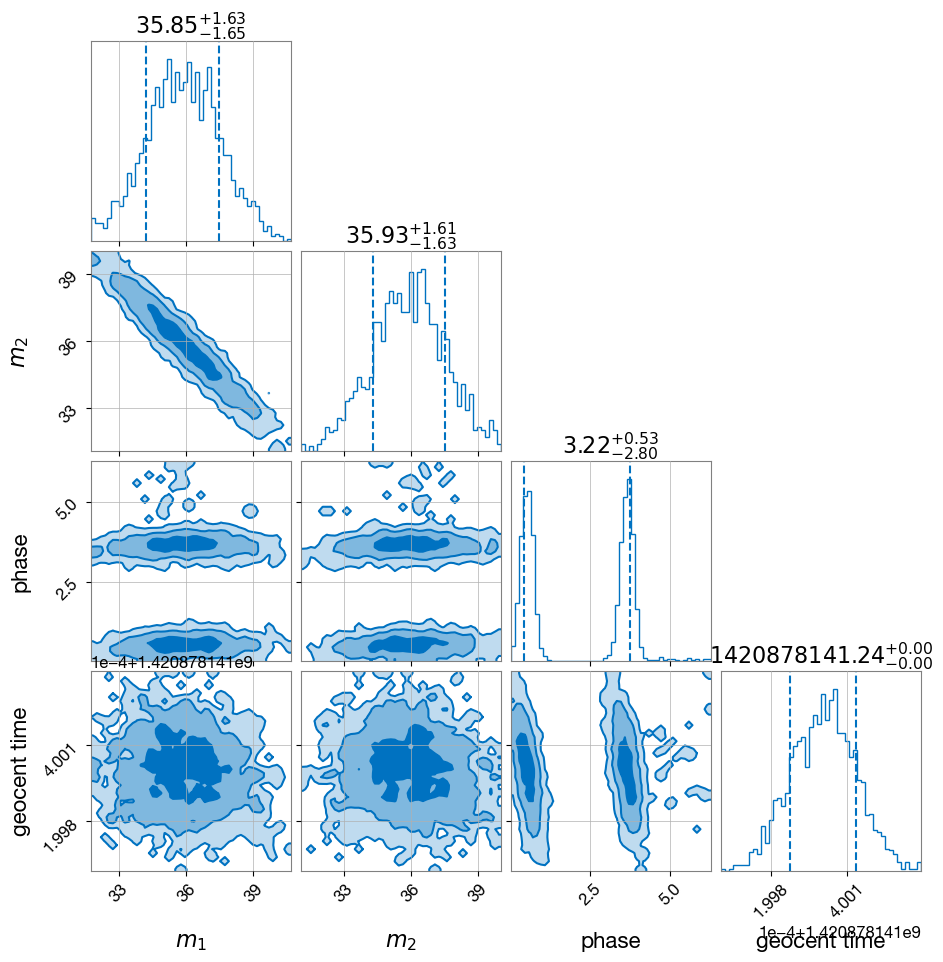

In [99]:

result_pe.plot_corner(parameters=['mass_1', 'mass_2', 'phase', 'geocent_time'], prior=True)

After the run finishes, compare the posterior with the catalog masses printed above. Because this is a deliberately small and pedagogical run, the goal is not to reproduce the published analysis exactly, but to show how the inference machinery is wired together.